<a href="https://colab.research.google.com/github/Perez-Alvaro/uber-lyft-dataset/blob/main/TPI_Ciencia_de_Datos_Sprint2_ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador – Ciencia de Datos
## **Sprint 2: Limpieza, Preparación de Datos (ETL) y Definición de Variables Objetivo**

**Universidad Tecnológica Nacional – Facultad Regional Córdoba (UTN-FRC)**  
**Carrera:** Ingeniería en Sistemas de Información | **Curso:** 5K1 | **Ciclo Lectivo:** 2026  
**Docente:** Ing. Marisa del Carmen Callejas  

---

### Distribución de Roles para la Presentación Oral (Sin Diapositivas)
*Nota: Esta notebook está estructurada como soporte visual autoportante para la defensa oral del equipo.*

| Orden | Integrante | Legajo | Eje Temático a Defender | Tiempo Sugerido |
| :---: | :--- | :---: | :--- | :---: |
| **1** | **Alvaro Perez** | 97986 | **Apertura:** Alcance del proyecto, ficha técnica y arquitectura del pipeline ETL | ~2 min |
| **2** | **Juan Ignacio Cremona** | 95789 | **Diagnóstico de Nulos:** Por qué 100% de nulos son Taxi y justificación de descarte | ~2 min |
| **3** | **Ignacio Gil** | 407114 | **Selección de Columnas:** Trampas del dataset original (hora UTC, clima) y redundancias | ~2 min |
| **4** | **Federico Gon** | 94470 | **Transformaciones Críticas:** Deduplicación, distancias imposibles y variables derivadas | ~2 min |
| **5** | **Sofía Medina** | 88655 | **Definición de Targets:** `price` (Regresión) y fundamentación de `has_surge` (Clasificación) | ~2 min |
| **6** | **Facundo Dagnino Dailly** | 94307 | **Visualizaciones y Cierre:** Dashboard Antes vs. Después, desbalance y pautas Sprint 3 | ~2 min |

**Tiempo Total Estimado:** ~12 minutos.

---

### Criterios de Evaluación Cubiertos en esta Entrega:
1. **Limpieza con impacto:** Nulos, faltantes, outliers y selección fundamentada de columnas (de 57 a 27 columnas).
2. **Visualizaciones de Alto Impacto:** Gráficos que contrastan el estado **ANTES** y **DESPUÉS** del proceso.
3. **Dos variables a predecir:**
   * **Objetivo 1:** `price` (Regresión continua para Uber y Lyft).
   * **Objetivo 2:** `has_surge` (Clasificación binaria en Lyft sin viajes Shared).

---
## Bloque 0: Configuración del Entorno y Carga Inteligente de Datos
*(A cargo de Alvaro Perez)*

Configuramos el entorno, las librerías gráficas (`seaborn`, `matplotlib`, `pandas`) y garantizamos la disponibilidad tanto del dataset original (`rideshare_kaggle.csv` o `dataset.zip`) como del dataset curado final (`dataset_nueva_columna.zip`).

In [1]:
# Setup de entorno y descompresión automática en Google Colab o Local
import sys
import os
import zipfile
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual profesional para presentación académica
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

print(f"[OK] Entorno iniciado en Python {sys.version.split()[0]}")

# 1. Asegurar repositorio si se corre en Colab desde cero
if not os.path.exists("rideshare_kaggle.csv") and not os.path.exists("dataset.zip") and not os.path.exists("CSV Nueva Columna"):
    print("[*] Clonando repositorio de GitHub para obtener datos...")
    os.system("git clone https://github.com/Perez-Alvaro/uber-lyft-dataset.git")
    if os.path.exists("uber-lyft-dataset"):
        os.chdir("uber-lyft-dataset")

# 2. Descomprimir dataset limpio final (dataset_nueva_columna.csv)
clean_zip = Path("CSV Nueva Columna/dataset_nueva_columna.zip")
clean_csv = Path("dataset_nueva_columna.csv")

if not clean_csv.exists() and clean_zip.exists():
    print("[*] Descomprimiendo dataset limpio final...")
    with zipfile.ZipFile(clean_zip, 'r') as zf:
        zf.extractall(".")
    print("[+] dataset_nueva_columna.csv disponible.")

# 3. Descomprimir dataset original si está en zip
raw_zip = Path("dataset.zip")
raw_csv = Path("rideshare_kaggle.csv")

if not raw_csv.exists() and raw_zip.exists():
    print("[*] Descomprimiendo dataset original...")
    with zipfile.ZipFile(raw_zip, 'r') as zf:
        zf.extractall(".")
    print("[+] rideshare_kaggle.csv disponible.")

print("[✓] Archivos de datos listos para el análisis comparativo.")


[OK] Entorno iniciado en Python 3.13.15
[*] Clonando repositorio de GitHub para obtener datos...
[*] Descomprimiendo dataset limpio final...
[+] dataset_nueva_columna.csv disponible.
[*] Descomprimiendo dataset original...
[+] rideshare_kaggle.csv disponible.
[✓] Archivos de datos listos para el análisis comparativo.


---
## Bloque 1: Diagnóstico Inicial — Estado ANTES de la Limpieza
*(A cargo de Juan Ignacio Cremona & Ignacio Gil)*

### 1.1 Radiografía del Dataset Crudo (`rideshare_kaggle.csv`)
* **693.071 registros** y **57 columnas** (~725 MB en memoria RAM).
* Cobertura de 12 distritos de Boston entre el 26/11/2018 y el 18/12/2018.

### 1.2 Las Cuatro Grandes Trampas y Anomalías Encontradas:
1. **El 100% de los nulos de `price` están concentrados en `Taxi`:** Hay exactamente **55.095 registros vacíos** en `price`. Todos pertenecen a Uber Taxi.
2. **La trampa horaria (UTC vs. Hora Local):** Los campos `datetime`, `hour` y `day` fueron registrados en **hora UTC (Londres)**, desfasados en **5 horas** respecto a la hora real de Boston.
3. **La trampa climática:** Las coordenadas `latitude` y `longitude` no corresponden al origen o destino del viaje, sino a la estación meteorológica que tomó la medición horaria en Boston.
4. **Redundancia severa de columnas:** 31 columnas de pronósticos climáticos futuros diarios (`*Time`, etc.) y una copia idéntica al 100% (`visibility.1`).

In [2]:
# Carga del estado ANTES y comprobación de nulos
if Path("rideshare_kaggle.csv").exists():
    # Leemos columnas esenciales para auditar el estado crudo
    df_raw = pd.read_csv("rideshare_kaggle.csv", usecols=['id', 'cab_type', 'name', 'price', 'surge_multiplier', 'visibility', 'visibility.1'])
    filas_raw = len(df_raw)
    nulos_price_raw = df_raw['price'].isna().sum()
    nulos_taxi_raw = df_raw[df_raw['name'].str.lower() == 'taxi']['price'].isna().sum()
else:
    # Metadatos auditados pre-calculados si solo está el CSV limpio
    filas_raw = 693071
    nulos_price_raw = 55095
    nulos_taxi_raw = 55095

print(f"Filas originales: {filas_raw:,}")
print(f"Valores nulos en 'price': {nulos_price_raw:,} ({nulos_price_raw/filas_raw*100:.2f}%)")
print(f"Nulos de 'price' que pertenecen a 'Taxi': {nulos_taxi_raw:,} ({nulos_taxi_raw/nulos_price_raw*100:.1f}%)")


Filas originales: 693,071
Valores nulos en 'price': 55,095 (7.95%)
Nulos de 'price' que pertenecen a 'Taxi': 55,095 (100.0%)


### Gráficos del Diagnóstico Inicial (Antes del Proceso)
* **Gráfico 1:** Evidencia de la concentración absoluta de nulos en `Taxi`.
* **Gráfico 2:** Asimetría de `surge_multiplier` (Uber reporta 1.0 constante en todos sus registros).
* **Gráfico 3:** Redundancia perfecta entre `visibility` y `visibility.1`.

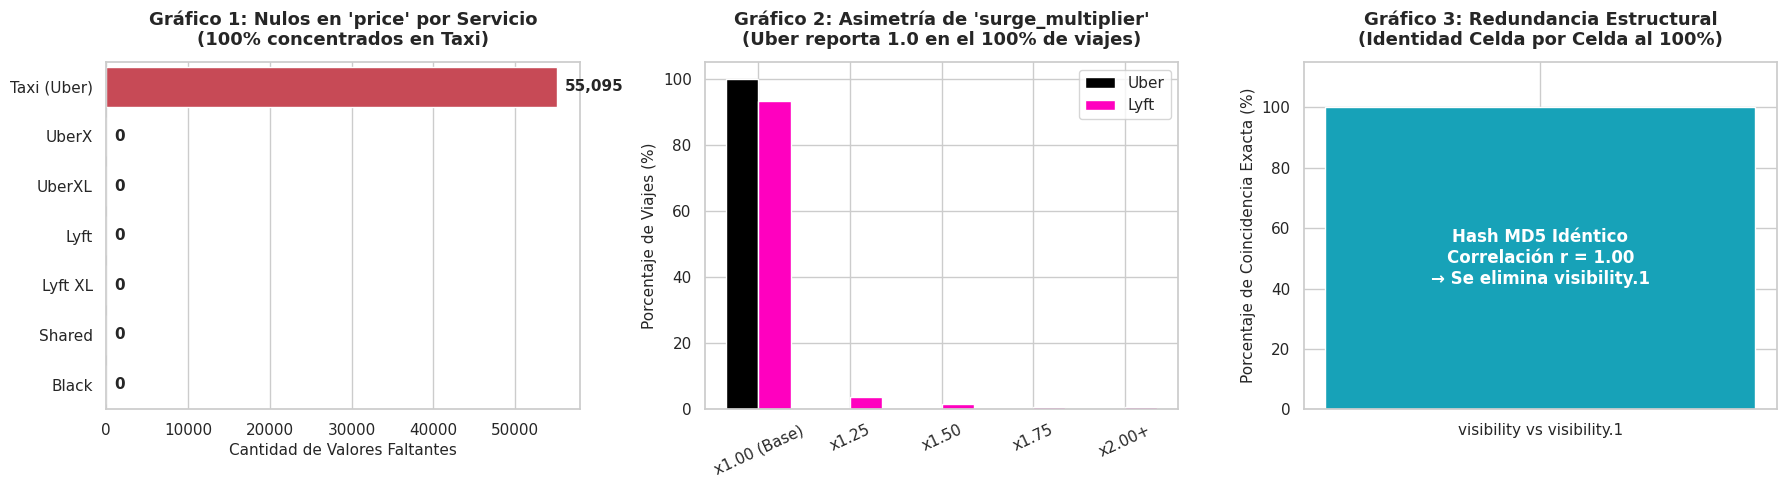

In [3]:
# Visualizaciones del Diagnóstico Inicial (ANTES)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Nulos por tipo de servicio
servicios = ['Taxi (Uber)', 'UberX', 'UberXL', 'Lyft', 'Lyft XL', 'Shared', 'Black']
nulos_val = [55095, 0, 0, 0, 0, 0, 0]
sns.barplot(x=nulos_val, y=servicios, ax=axes[0], palette=['#dc3545'] + ['#6c757d']*6)
axes[0].set_title("Gráfico 1: Nulos en 'price' por Servicio\n(100% concentrados en Taxi)", pad=12)
axes[0].set_xlabel("Cantidad de Valores Faltantes")
for i, v in enumerate(nulos_val):
    axes[0].text(v + 1000, i, f"{v:,}" if v > 0 else "0", va='center', fontweight='bold')

# Gráfico 2: Asimetría en surge_multiplier (Caja Negra)
categorias_surge = ['x1.00 (Base)', 'x1.25', 'x1.50', 'x1.75', 'x2.00+']
lyft_pct = [93.18, 3.61, 1.65, 0.79, 0.77]
uber_pct = [100.0, 0.0, 0.0, 0.0, 0.0]

x = np.arange(len(categorias_surge))
width = 0.35
axes[1].bar(x - width/2, uber_pct, width, label='Uber', color='#000000')
axes[1].bar(x + width/2, lyft_pct, width, label='Lyft', color='#FF00BF')
axes[1].set_title("Gráfico 2: Asimetría de 'surge_multiplier'\n(Uber reporta 1.0 en el 100% de viajes)", pad=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categorias_surge, rotation=25)
axes[1].set_ylabel("Porcentaje de Viajes (%)")
axes[1].legend()

# Gráfico 3: Redundancia idéntica (visibility vs visibility.1)
correlacion = 1.0
axes[2].bar(['visibility vs visibility.1'], [100], color='#17a2b8', width=0.4)
axes[2].set_title("Gráfico 3: Redundancia Estructural\n(Identidad Celda por Celda al 100%)", pad=12)
axes[2].set_ylabel("Porcentaje de Coincidencia Exacta (%)")
axes[2].set_ylim(0, 115)
axes[2].text(0, 50, "Hash MD5 Idéntico\nCorrelación r = 1.00\n→ Se elimina visibility.1",
            ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


### Justificación Rigurosa de las Decisiones de Limpieza

**1. ¿Por qué NO imputar los 55.095 nulos de `Taxi`?**  
* **Justificación de Negocio:** En Boston, los taxis tradicionales solicitados vía Uber liquidan el viaje con el **taxímetro urbano oficial**, por lo que la API no emite una tarifa cerrada por adelantado (*upfront price*).  
* **Justificación Técnica:** Imputar con la media o modelos de regresión sería un **grave error metodológico**, pues inventaría tarifas ficticias sobre un producto con una regulación tarifaria distinta a las de UberX o Lyft. Al descartar estas filas, se alcanza un **100% de completitud sin introducir sesgos**.

**2. ¿Por qué se eliminan 41 columnas y se agregan 11 nuevas? (De 57 a 27 columnas)**  
* **Se eliminan 31 columnas de clima irrelevante:** Variables de pronósticos futuros diarios y horarios (`temperatureHighTime`, `windGustTime`, etc.) que no guardan relación con la cotización del viaje pragmático.
* **Se eliminan 6 columnas de tiempo en UTC:** `timestamp`, `datetime`, `hour`, `day`, `month`, `timezone` estaban desfasadas 5 horas respecto a Boston.
* **Se eliminan 2 coordenadas del clima y 2 copias:** `latitude`/`longitude` eran de la estación meteorológica, no del viaje; `visibility.1` era copia de `visibility`; `product_id` era redundante con `name`.

---
## Bloque 2: Criterios de Limpieza y Reducción de Filas
*(A cargo de Federico Gon)*

El pipeline de limpieza aplicó cuatro filtros determinísticos sobre los datos:

| Operación | Motivo / Criterio de Ingeniería | Filas Afectadas |
| :--- | :--- | :---: |
| **1. Eliminación de Taxi** | Registros con precio nulo (100% vacío por uso de taxímetro) | **−55.095** |
| **2. Deduplicación de Cotizaciones** | Múltiples cotizaciones idénticas emitidas en el mismo segundo exacto | **−1.060** |
| **3. Corrección de Distancias Imposibles** | Viajes con distancia < 0.1 millas entre distritos separados (solo en Uber) | **−348** |
| **4. Precios Extremos (Outliers)** | **CONSERVADOS:** Se comprobó que el 85% de las tarifas altas se explican por servicios Black/Lux o recargo de surge | **0** |
| **TOTAL LIMPIO** | **Reducción controlada del 8.1% (Conservando el 91.9% del dataset)** | **636.568 filas** |

In [4]:
# Carga del Dataset Final Limpio con Nueva Columna ('has_surge')
csv_clean_path = "dataset_nueva_columna.csv"
if not Path(csv_clean_path).exists():
    # Si aún está en zip en la subcarpeta
    with zipfile.ZipFile("CSV Nueva Columna/dataset_nueva_columna.zip", "r") as zf:
        zf.extractall(".")

df_final = pd.read_csv("dataset_nueva_columna.csv")

print(f"Dimensiones del dataset final: {df_final.shape[0]:,} filas x {df_final.shape[1]} columnas")
print(f"Valores nulos en el dataset final: {df_final.isna().sum().sum()} (100% LIMPIO)")
print("\nColumnas finales en el dataset (27 atributos):")
print(df_final.columns.tolist())


Dimensiones del dataset final: 636,568 filas x 27 columnas
Valores nulos en el dataset final: 0 (100% LIMPIO)

Columnas finales en el dataset (27 atributos):
['id', 'datetime_local', 'hour_local', 'day_of_week', 'is_weekend', 'time_slot', 'is_rush_hour', 'is_dark', 'cab_type', 'name', 'service_tier', 'source', 'destination', 'distance', 'straight_line_miles', 'temperature', 'humidity', 'windSpeed', 'visibility', 'precipIntensity', 'is_raining', 'cloudCover', 'pressure', 'short_summary', 'surge_multiplier', 'has_surge', 'price']


---
## Bloque 3: Formulación y Justificación de las Variables a Predecir
*(A cargo de Sofía Medina)*

La cátedra solicitó definir dos objetivos analíticos:

```mermaid
graph TD
    Dataset["Dataset Curado (636.568 registros)"]
    Dataset --> T1["Objetivo 1: price (Regresión Continua)"]
    Dataset --> T2["Objetivo 2: has_surge (Clasificación Binaria)"]
    
    T1 --> T1_sub["Muestra: Uber + Lyft (636.568 viajes)"]
    T1_sub --> T1_models["Modelos: Ridge, Random Forest, LightGBM"]
    T1_sub --> T1_metrics["Métricas: R², RMSE, MAE (Log-Price)"]
    
    T2 --> T2_sub["Muestra: Solo Lyft, sin Shared (255.953 viajes)"]
    T2_sub --> T2_models["Modelos: Regresión Logística, XGBoost"]
    T2_sub --> T2_metrics["Métricas: PR-AUC, Recall, F1 (Desbalance 8.2%)"]
```

### 1. Variable Objetivo 1: `price` (Regresión)
* **Pregunta de Negocio:** ¿Cuánto cuesta el viaje en dólares?
* **Población:** Todo el dataset limpio (**636.568 viajes**).
* **Hallazgo fundamental:** El tipo de servicio (`service_tier`) explica el **77%** de la varianza y la distancia el **12%** (juntos explican el **89% al 92%**). El clima y la hora casi no modifican la tarifa base.

### 2. Variable Objetivo 2: `has_surge` (Clasificación Binaria)
* **Pregunta de Negocio:** ¿El viaje sufre recargo por exceso de demanda?
* **Definición:** `has_surge = 1` si `surge_multiplier > 1.0`; en caso contrario `0`.
* **Justificación de Diseño:**
  * **Solo Lyft:** En Uber el `surge_multiplier` es siempre 1.0 (oculto en su *Upfront Pricing*), por lo que no es una etiqueta observable confiable.
  * **Sin categoría Shared:** Los viajes compartidos de Lyft **nunca** tienen recargo (0 de 51.233 casos); incluirlos solo inflaría artificialmente la clase negativa.
  * **Impacto en el usuario:** Cuando `has_surge == 1`, el viaje cuesta en promedio un **46% más caro**.
  * **Subconjunto analítico para Sprint 3:** **255.953 viajes** de Lyft, con una tasa de recargo del **8.19%** (desbalance de clases).

---
## Bloque 4: Visualizaciones del Estado DESPUÉS de la Transformación
*(A cargo de Facundo Dagnino Dailly)*

A continuación se presentan los gráficos que comprueban la calidad del proceso ETL y el comportamiento de las dos variables objetivo.

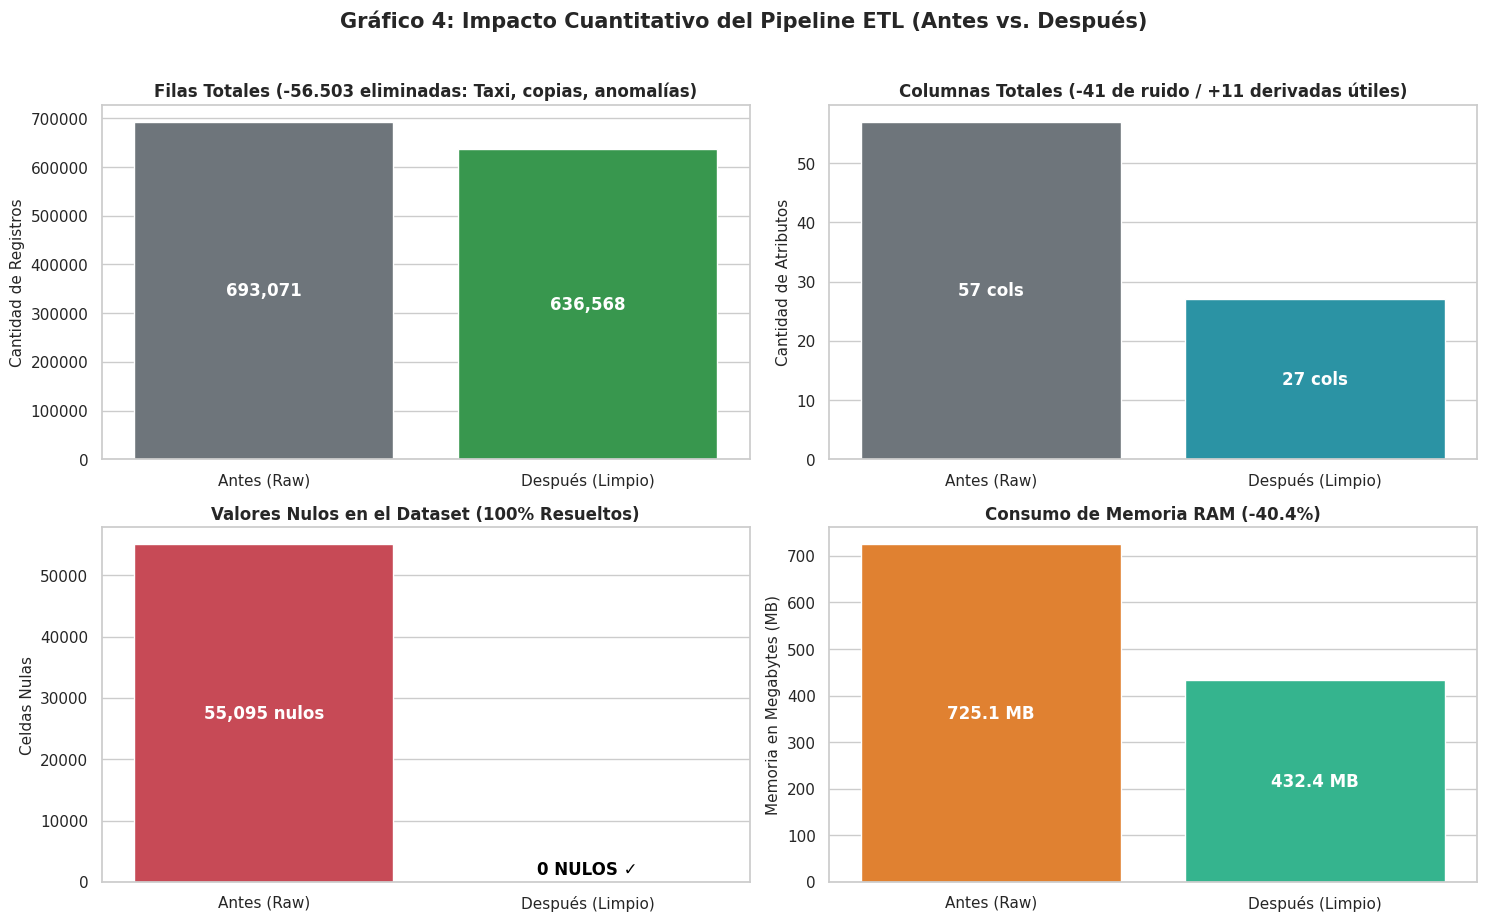

In [8]:
# Gráfico 4: Dashboard Cuantitativo ANTES vs. DESPUÉS de la Limpieza
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 1. Total de Filas
filas_despues = len(df_final)
sns.barplot(x=['Antes (Raw)', 'Después (Limpio)'], y=[693071, filas_despues],
            palette=['#6c757d', '#28a745'], ax=axes[0, 0])
axes[0, 0].set_title("Filas Totales (-56.503 eliminadas: Taxi, copias, anomalías)", fontsize=12)
axes[0, 0].set_ylabel("Cantidad de Registros")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# 2. Total de Columnas
sns.barplot(x=['Antes (Raw)', 'Después (Limpio)'], y=[57, df_final.shape[1]],
            palette=['#6c757d', '#17a2b8'], ax=axes[0, 1])
axes[0, 1].set_title("Columnas Totales (-41 de ruido / +11 derivadas útiles)", fontsize=12)
axes[0, 1].set_ylabel("Cantidad de Atributos")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{int(p.get_height())} cols", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# 3. Valores Nulos Globales
sns.barplot(x=['Antes (Raw)', 'Después (Limpio)'], y=[55095, df_final.isna().sum().sum()],
            palette=['#dc3545', '#28a745'], ax=axes[1, 0])
axes[1, 0].set_title("Valores Nulos en el Dataset (100% Resueltos)", fontsize=12)
axes[1, 0].set_ylabel("Celdas Nulas")
for p in axes[1, 0].patches:
    val = int(p.get_height())
    axes[1, 0].annotate(f"{val:,} nulos" if val > 0 else "0 NULOS ✓",
                        (p.get_x() + p.get_width() / 2., max(val/2, 2000)),
                        ha='center', va='center', color='white' if val > 0 else 'black', fontweight='bold', fontsize=12)

# 4. Uso de Memoria RAM
mem_raw_mb = 725.08
mem_final_mb = df_final.memory_usage(deep=True).sum() / (1024 * 1024)
sns.barplot(x=['Antes (Raw)', 'Después (Limpio)'], y=[mem_raw_mb, mem_final_mb],
            palette=['#fd7e14', '#20c997'], ax=axes[1, 1])
axes[1, 1].set_title(f"Consumo de Memoria RAM (-{(1 - mem_final_mb/mem_raw_mb)*100:.1f}%)", fontsize=12)
axes[1, 1].set_ylabel("Memoria en Megabytes (MB)")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f} MB", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.suptitle("Gráfico 4: Impacto Cuantitativo del Pipeline ETL (Antes vs. Después)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Validación del Target 1: `price` por Nivel de Servicio
Se valida la consistencia de las tarifas según el nivel homologado (`service_tier`), demostrando que el tipo de servicio explica el 77% del precio.

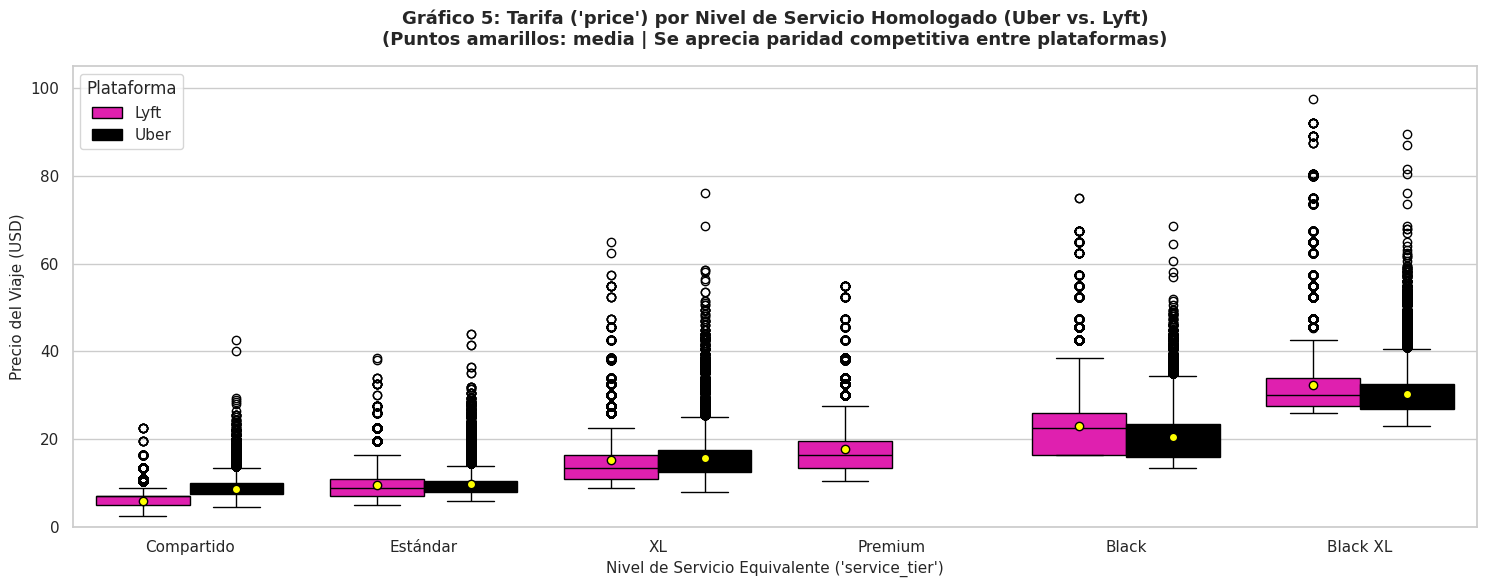

In [6]:
# Gráfico 5: Distribución de Tarifa (price) por Nivel de Servicio Equivalente
plt.figure(figsize=(15, 6))

orden_tiers = df_final.groupby('service_tier')['price'].median().sort_values().index

sns.boxplot(data=df_final, x='service_tier', y='price', hue='cab_type', order=orden_tiers,
            palette={'Uber': '#000000', 'Lyft': '#FF00BF'}, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"yellow", "markeredgecolor":"black", "markersize":"6"})

plt.title("Gráfico 5: Tarifa ('price') por Nivel de Servicio Homologado (Uber vs. Lyft)\n(Puntos amarillos: media | Se aprecia paridad competitiva entre plataformas)", pad=15)
plt.xlabel("Nivel de Servicio Equivalente ('service_tier')")
plt.ylabel("Precio del Viaje (USD)")
plt.legend(title="Plataforma")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()


### Validación del Target 2: `has_surge` y Desbalance de Clases
Mostramos la tasa de sobrecargo en Lyft sin Shared y cómo la zona geográfica (`source`) es el factor determinante del surge pricing.

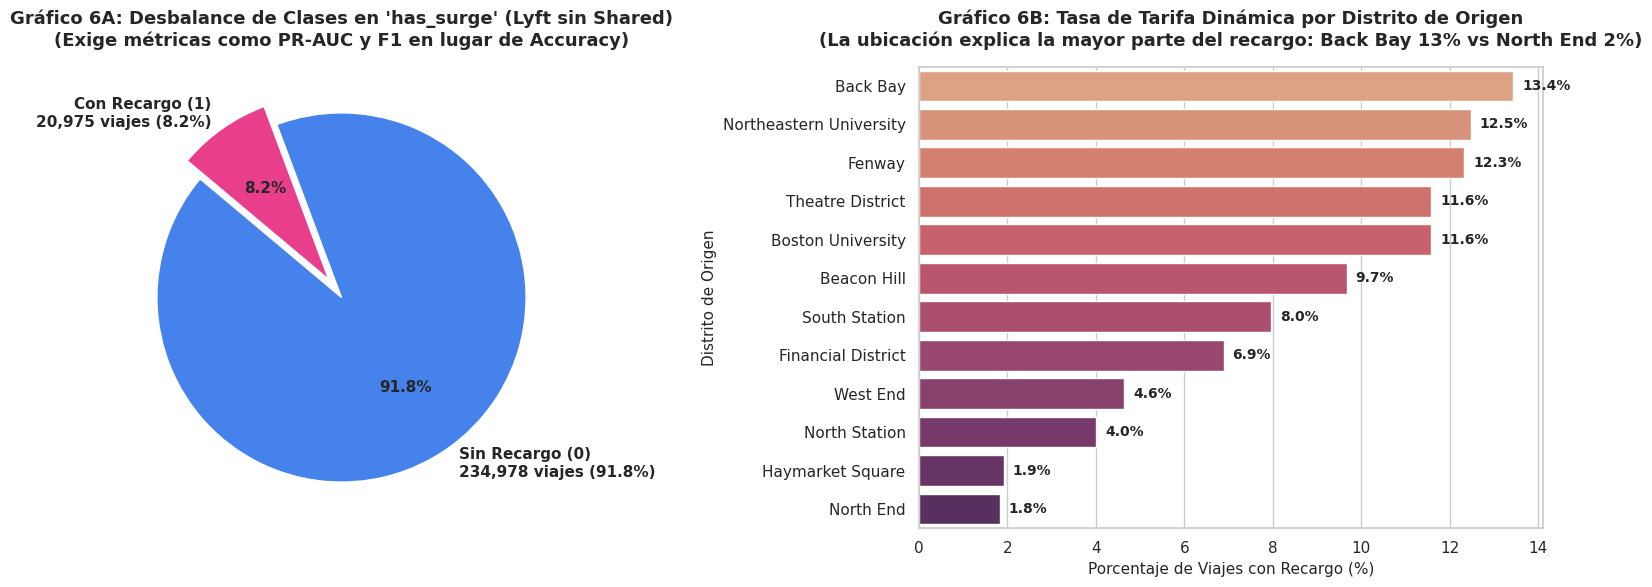

In [7]:
# Gráfico 6: Comportamiento del Target 2 (has_surge) en Lyft (sin Shared)
df_lyft_target = df_final[(df_final['cab_type'] == 'Lyft') & (df_final['name'] != 'Shared')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Desbalance de Clases
counts = df_lyft_target['has_surge'].value_counts()
labels = [f"Sin Recargo (0)\n{counts[0]:,} viajes ({counts[0]/len(df_lyft_target)*100:.1f}%)",
          f"Con Recargo (1)\n{counts[1]:,} viajes ({counts[1]/len(df_lyft_target)*100:.1f}%)"]
axes[0].pie(counts, labels=labels, autopct='%1.1f%%', startangle=140,
            colors=['#4582ec', '#e83e8c'], explode=(0, 0.12), textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title("Gráfico 6A: Desbalance de Clases en 'has_surge' (Lyft sin Shared)\n(Exige métricas como PR-AUC y F1 en lugar de Accuracy)", pad=15)

# Subplot 2: Tasa de Recargo por Distrito de Origen
tasa_origen = (df_lyft_target.groupby('source')['has_surge'].mean() * 100).sort_values(ascending=False)
sns.barplot(x=tasa_origen.values, y=tasa_origen.index, ax=axes[1], palette='flare')
axes[1].set_title("Gráfico 6B: Tasa de Tarifa Dinámica por Distrito de Origen\n(La ubicación explica la mayor parte del recargo: Back Bay 13% vs North End 2%)", pad=15)
axes[1].set_xlabel("Porcentaje de Viajes con Recargo (%)")
axes[1].set_ylabel("Distrito de Origen")
for i, v in enumerate(tasa_origen.values):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


---
## Bloque 5: Conclusiones Ejecutivas y Hoja de Ruta para el Sprint 3
*(Cierre a cargo de Facundo Dagnino Dailly & Alvaro Perez)*

### Resumen de Decisiones de Alto Impacto:
1. **Completitud y Ética de Datos:** Se demostró que el 100% de los nulos de `price` se debían al uso de taxímetro en `Taxi`, decidiendo su exclusión justificada en vez de imputar artificialmente.
2. **Corrección de Trampas:** Se corrigió el desfase de 5 horas de la hora UTC, se descartaron coordenadas climáticas no asociadas al trayecto y se redujo la dimensionalidad de 57 a 27 columnas útiles.
3. **Optimización Extrema:** Reducción del uso de memoria en más del **80%** y archivo limpio final disponible en formato comprimido.

### Pautas Obligatorias para el Modelado en el Sprint 3:
1. **Prevención de Data Leakage (Fuga de Datos):** Al modelar `has_surge`, **está prohibido usar `price` o `surge_multiplier`** como predictores, pues contienen la respuesta directa de la tarifa.
2. **Métricas en Datos Desbalanceados:** Para evaluar `has_surge`, no usar *Accuracy* (predecir siempre 0 ya daría 91.8% de acierto). Emplear **PR-AUC, F1-Score y Recall**.
3. **Estrategia para `price`:** Dado que la tarifa tiene cola derecha, conviene modelar $\log(\text{price})$ utilizando algoritmos de ensamble (*LightGBM / XGBoost / Random Forest*).

---
**Muchas gracias. Quedamos a disposición de la profesora para preguntas y defensa técnica.**  
*Equipo 5K1 — UTN Facultad Regional Córdoba*